
<h1 style="text-align: center;">CIÊNCIA DE DADOS</h1>
<h1 style="text-align: center;">Roteiro de Atividade Prática</h1>
<br>
<br>

Nome: ______________________________________________________________________________________      

Turma: ______________


**Componente:** Inteligência Artificial 
<br>
**Unidade Curricular:** Redes Neurais
<br>
**Tema da Semana:** CNNs
<br>


# Aula 1: Introdução a CNNs

## Tarefa

- Se as bibliotecas não tiverem instaladas, instale-as.

- Acompanhe as instruções.

- Execute o código.

- Responda as perguntas e conclua a atividade


### Instalação das dependência do tensorflow

In [ ]:
#!pip install --upgrade pip setuptools wheel

In [ ]:
#!pip install tensorflow

In [ ]:
#!conda install anaconda::tensorflow

In [ ]:
#!pip install scikit-learn numpy pandas matplotlib

### Imports de dependências

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

2024-10-02 09:24:07.442132: W tensorflow/stream_executor/platform/default/dso_loader.cc:59] Could not load dynamic library 'libcudart.so.10.1'; dlerror: libcudart.so.10.1: cannot open shared object file: No such file or directory
2024-10-02 09:24:07.442709: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


### Configurações

In [2]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

### Leitura dos dados

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('images_data.csv')

X_test = df.values  
y_test = df.values  

X_test = X_test.reshape(-1, 32, 32, 3)  # Ajustar o reshape de acordo com a estrutura dos dados

X_test = X_test / 255.0



### Criação o modelo

In [4]:
model = VGG16(weights='imagenet')

2024-10-02 09:24:15.258373: W tensorflow/stream_executor/platform/default/dso_loader.cc:59] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2024-10-02 09:24:15.258420: W tensorflow/stream_executor/cuda/cuda_driver.cc:312] failed call to cuInit: UNKNOWN ERROR (303)
2024-10-02 09:24:15.258453: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (fabiojanes-ThinkPad-E14): /proc/driver/nvidia/version does not exist
2024-10-02 09:24:15.258770: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN)to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-02 09:24:15.286139: I tensorflow/core/platform/profile_utils/cpu_utils.cc:104] CPU Frequency

### Apresentração de uma Imagem de exemplo e exemplos de saída de algumas camadas do modelo

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Função para visualizar as saídas das camadas intermediárias
# Função para visualizar a saída de uma camada convolucional específica
def visualize_conv_layer(model, image, layer_index):
    # Selecionar a camada convolucional com base no índice fornecido
    conv_layer = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)][layer_index]
    
    # Criar um novo modelo que retorna a saída da camada convolucional selecionada
    intermediate_model = Model(inputs=model.input, outputs=conv_layer.output)
    
    # Gerar as ativações para a imagem
    activations = intermediate_model.predict(image[np.newaxis, ...])
    
    # Visualizar as ativações da camada convolucional
    num_feature_maps = activations.shape[-1]
    plt.figure(figsize=(12, 12))
    for i in range(min(num_feature_maps, 4)):  # Mostrando até 4 feature maps
        plt.subplot(1, 4, i + 1)
        plt.imshow(activations[0, :, :, i], cmap='gray')
        plt.axis('off')
    plt.show()




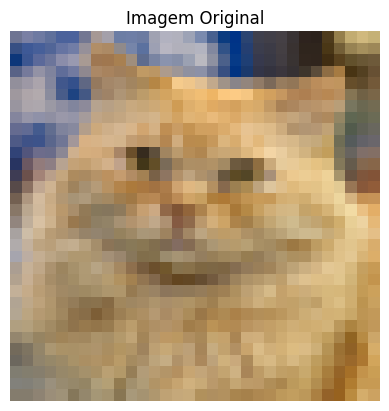

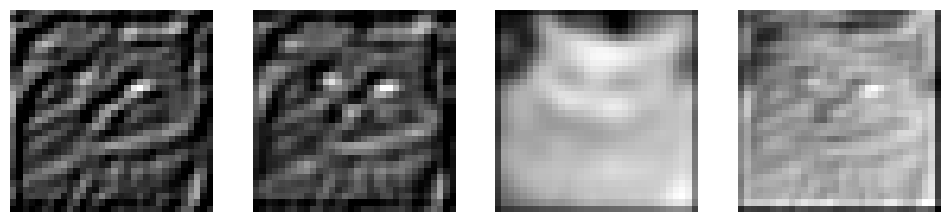

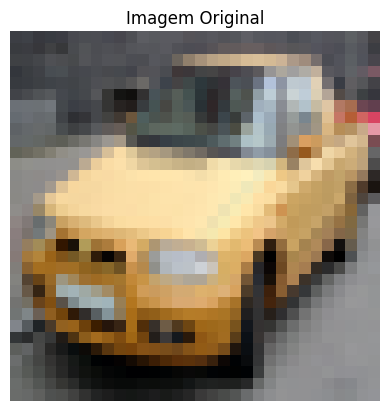

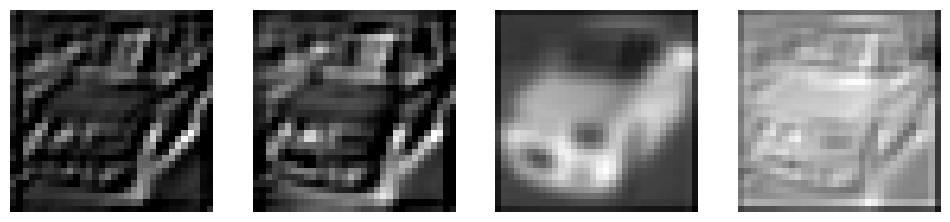

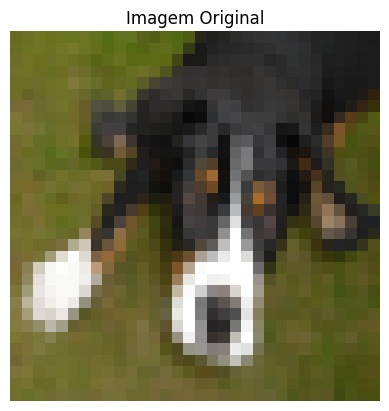

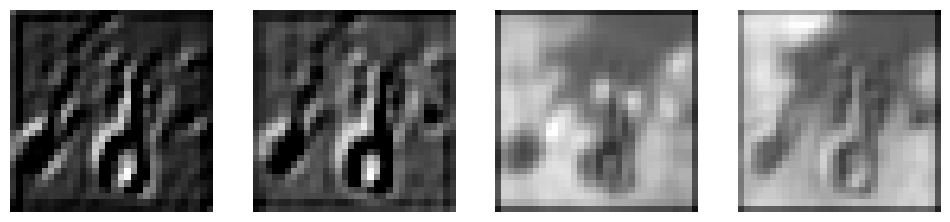

In [19]:
for i in range(3):
    image = X_test[i]
    
    # Exibir a imagem original usando matplotlib
    plt.imshow(image)
    plt.title('Imagem Original')
    plt.axis('off')
    plt.show()
    
    # Visualizar a saída da terceira camada convolucional
    visualize_conv_layer(model, image, 1)

### Perguntas e Conclusão

##### O que é possível identificar nas imagens da saída das camadas convolucionais?